# Homework 4: Data Preprocessing, Feature Selection, and Model Training
## For this assignment I'll use Soccer Dataset for the FIFA WorldCup Data. Data can be found at https://www.football-data.co.uk/

#### The following documentation was created with AI in order to have a description of the data.

## Soccer Dataset Data Dictionary

### 1. General Match Information
| Column | Description |
| :--- | :--- |
| `Competition` | Name of the league or tournament |
| `Home` | Home team name |
| `Away` | Away team name |
| `Date` | Match date |
| `Time` | Kick-off time |
| `Type` | Stage or fixture type (e.g., Group Stage, Knockout, Qualifier) |
| `Finished` | Indicates if the match completed normally |

### 2. Goals & Scores Breakdown
| Column | Description |
| :--- | :--- |
| `HG` / `HGFT` | Home Goals Full Time (Final score) |
| `AG` / `AGFT` | Away Goals Full Time (Final score) |
| `HG1st` / `AG1st` | Home / Away goals scored in the 1st half |
| `HG2nd` / `AG2nd` | Home / Away goals scored in the 2nd half |
| `HGET` / `AGET` | Home / Away goals scored during Extra Time (Knockouts) |
| `HGP` | Home Goals in Penalty Shootout |
| `HGP.1` | Away Goals in Penalty Shootout (*Duplicate `HGP` column auto-renamed by pandas*) |

### 3. In-Game Match Statistics
| Column | Description |
| :--- | :--- |
| `HS` / `AS` | Home / Away total Shots |
| `HST` / `AST` | Home / Away Shots on Target |
| `HF` / `AF` | Home / Away Fouls committed |
| `HC` / `AC` | Home / Away Corners taken |
| `HY` / `AY` | Home / Away Yellow Cards |
| `HR` / `AR` | Home / Away Red Cards |

### 4. Advanced Analytics
| Column | Description |
| :--- | :--- |
| `HxG` | **Home Expected Goals** (Quality/probability of chances created by home team) |
| `AxG` | **Away Expected Goals** (Quality/probability of chances created by away team) |

### 5. Betting Odds (1X2 Market)
> **Note:** `H` = Home Win, `D` = Draw, `A` = Away Win

| Column | Description |
| :--- | :--- |
| `bet365-H` / `D` / `A` | Closing odds from Bet365 |
| `Betfair_Exch-H` / `D` / `A` | Closing exchange odds from Betfair |
| `Pinny-H` / `D` / `A` | Closing odds from Pinnacle (Sharp bookmaker) |
| `H-Max` / `D-Max` / `A-Max` <br> (`H_Max` / `D_Max` / `A_Max`) | Maximum odds available across all surveyed bookmakers |
| `H-Avg` / `D-Avg` / `A-Avg` <br> (`H_Avg` / `D_Avg` / `A_Avg`) | Average odds available across all surveyed bookmakers |

In [62]:
import pandas as pd
PATH = "datasets/WorldCup2026.xlsx"
df_2026 = pd.read_excel(PATH, sheet_name="WorldCup2026")
df_QF = pd.read_excel(PATH, sheet_name="WorldCup2026Qualifiers")
df_2022 = pd.read_excel(PATH, sheet_name="WorldCup2022")
df_2018 = pd.read_excel(PATH, sheet_name="WorldCup2018")

#Types will be integers, 2026 for WorldCup2026, 2024 for WorldCup2026Qualifiers, 2022 for WorldCup2022 qnd 2018 for WorldCup2018.
df_2026['Year']= 2026
df_QF['Year']= 2024
df_2022['Year']= 2022
df_2018['Year']= 2018
df_QF['Competition']= 'World Cup 2026 Qualifiers'
df = pd.concat([df_2026,df_QF,df_2022,df_2018], ignore_index=True)
df.isna().groupby(df['Year']).sum()

,Competition,Home,Away,Date,Time,HGFT,AGFT,HG1st,AG1st,HG2nd,...,AG,H_Max,D_Max,A_Max,H_Avg,D_Avg,A_Avg,Pinny-H,Pinny-D,Pinny-A
Year,,,,,,,,,,,,,,,,,,,,,
2018,0,0,0,0,0,0,0,0,0,0,...,64,64,64,64,64,64,64,0,0,0
2022,0,0,0,0,0,0,0,0,0,0,...,64,64,64,64,64,64,64,64,64,64
2024,0,0,0,0,889,889,889,889,889,889,...,0,0,0,0,0,0,0,889,889,889
2026,0,0,0,0,0,0,0,0,0,0,...,104,104,104,104,104,104,104,104,104,104


In [63]:
df_2022.head()

,Competition,Home,Away,Date,Time,HGFT,AGFT,HG1st,AG1st,HG2nd,...,Betfair_Exch-H,Betfair_Exch-D,Betfair_Exch-A,H-Max,D-Max,A-Max,H-Avg,D-Avg,A-Avg,Year
0,World Cup 2022,Argentina,France,2022-12-18,15:00:00,2,2,2,0,0,...,2.76,3.15,3.05,2.70,3.20,2.90,2.63,3.12,2.84,2022
1,World Cup 2022,Croatia,Morocco,2022-12-17,15:00:00,2,1,2,1,0,...,2.32,3.75,3.25,2.25,3.60,3.15,2.23,3.49,3.09,2022
2,World Cup 2022,France,Morocco,2022-12-14,19:00:00,2,0,1,0,1,...,1.62,4.00,7.20,1.62,4.00,6.50,1.58,3.82,6.25,2022
3,World Cup 2022,Argentina,Croatia,2022-12-13,19:00:00,3,0,2,0,1,...,2.06,3.10,5.00,2.05,3.13,4.80,1.98,3.07,4.45,2022
4,World Cup 2022,England,France,2022-12-10,19:00:00,1,2,0,1,1,...,2.98,3.20,2.80,2.95,3.10,2.80,2.81,3.05,2.69,2022


In [64]:
#Creating more missing values randomly
import numpy as np

mask = np.random.rand(*df.shape)<0.2

df_missing = df.mask(mask)
df_missing.isna().groupby(df_missing['Year']).sum()

,Competition,Home,Away,Date,Time,HGFT,AGFT,HG1st,AG1st,HG2nd,...,AG,H_Max,D_Max,A_Max,H_Avg,D_Avg,A_Avg,Pinny-H,Pinny-D,Pinny-A
Year,,,,,,,,,,,,,,,,,,,,,
2018.0,11,9,14,9,10,9,8,11,12,14,...,52,52,52,52,52,52,52,15,12,8
2022.0,7,15,8,8,8,9,9,8,7,5,...,47,47,47,47,47,47,47,47,47,47
2024.0,138,130,141,139,727,727,727,727,727,727,...,152,152,145,134,123,146,151,727,727,727
2026.0,11,16,13,13,17,10,15,18,24,13,...,81,81,81,81,81,81,81,81,81,81


## PART 1 Data Preprocessing

### Compare the outputs of OneHotEncoder and OrdinalEncoder when applied to the categorical columns.
Applying OrdinalEncoder to the Competition column transformed each competition into a single numerical value while preserving the predefined order (WorldCup 2018 < WorldCup 2022 < WorldCup 2026 Qualifiers < WorldCup 2026. Therefore, applying OneHotEncoder to the Home and Away columns created separate binary columns for each team. Instead of assigning numerical ranks, each team is represented by a 1 if present and 0 otherwise. This increases the number of features but avoids introducing an artificial ordering.

### Which method is more appropriate for nominal data?
OneHotEncoder is more appropriate for nominal data because nominal categories do not have an order. Assigning numerical values with OrdinalEncoder could incorrectly imply that one category is less or greater than another. While OneHot Encoder treats each category independently.

In [65]:
#Get numeric filtered Columns
num_df = (
    df[["HS","AS","HST","AST"]].dropna().head(200).copy()
)

rng= np.random.default_rng(42)

for col in ["HS", "AS"]:
    missing_rows = rng.choice(
        num_df.index,
        size=20,
        replace=False
    )
    num_df.loc[missing_rows, col] = np.nan

In [86]:
from sklearn.impute import SimpleImputer
# Create an instance of SimpleImputer to replace missing values (NaN) using the column mean
imr = SimpleImputer(missing_values=np.nan, strategy='mean')

# Fit the imputer on the data (num_df.values) to compute the mean of each column
imr = imr.fit(num_df.values)

# Apply the imputer to transform the data by replacing missing values with the column mean
imputed_data = imr.transform(num_df.values)
# Output the dataset with imputed values
print(np.isnan(imputed_data).sum())

#Filling missing values using pandas
no_nan_pd = num_df.fillna(num_df.mean())

0


In [87]:
print("Shape of Numeric Dataset with Missing values: ",num_df.shape)
print("Shape of Imputed Array using SimpleImputer: ", imputed_data.shape)
print("Shape of Imputed Array using Pandas fillna(): ",no_nan_pd.shape)

Shape of Numeric Dataset with Missing values:  (200, 4)
Shape of Imputed Array using SimpleImputer:  (200, 4)
Shape of Imputed Array using Pandas fillna():  (200, 4)


In [88]:
rows_dropped = num_df.dropna(axis=0)
columns_dropped = num_df.dropna(axis=1)

print("Original:", num_df.shape)
print("Imputed:", imputed_data.shape)
print("Rows dropped:", rows_dropped.shape)
print("Columns dropped:", columns_dropped.shape)

Original: (200, 4)
Imputed: (200, 4)
Rows dropped: (160, 4)
Columns dropped: (200, 2)


Mean imputation preserved all 200 rows and 4 features. Dropping incomplete rows removed observations, while dropping columns removed the HS and AS features. Imputation preserves dataset shape but introduces estimated values.

In [69]:
df["Competition"].value_counts(dropna=False)

Competition
World Cup 2026 Qualifiers    889
World Cup 2026               104
World Cup 2022                64
World Cup 2018                64
Name: count, dtype: int64

In [70]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

competition_order = [[
    "World Cup 2018",
    "World Cup 2022",
    "World Cup 2026 Qualifiers",
    "World Cup 2026"
]]
competition_encoder = OrdinalEncoder(
    categories=competition_order
)

competition_encoded = competition_encoder.fit_transform(
    df[["Competition"]]
)

# Extract the 'color', 'size', and 'price' columns from the dataframe 'df' and store them in 'X' as a NumPy array
X = df[["Home","Away"]]

# Create an instance of OneHotEncoder to encode categorical 'color' values into one-hot vectors
team_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Apply the one-hot encoder to the 'color' column (which is the first column in X)
# The 'reshape(-1, 1)' is used to ensure the data is in the correct shape for the encoder (as a 2D array)
# 'fit_transform' fits the encoder and transforms the data, and 'toarray()' converts the sparse matrix to a dense NumPy array
teams_encoded = team_encoder.fit_transform(X)



In [90]:
#Now converting the competition encoder into a DF:
competition_encoded_df = pd.DataFrame(
    competition_encoded,
    columns=["Competition_encoder"],
    index=df.index
)
print(competition_encoded_df.head())

#Now converting the Nominal teams_encoded into a DF
teams_encoded_df = pd.DataFrame(
    teams_encoded,
    columns=team_encoder.get_feature_names_out(["Home", "Away"]),
    index=df.index
)
print(teams_encoded_df.head())

   Competition_encoder
0                  3.0
1                  3.0
2                  3.0
3                  3.0
4                  3.0
   Home_Afghanistan  Home_Albania  Home_Algeria  Home_Andorra  Home_Angola  \
0               0.0           0.0           0.0           0.0          0.0   
1               0.0           0.0           0.0           0.0          0.0   
2               0.0           0.0           0.0           0.0          0.0   
3               0.0           0.0           0.0           0.0          0.0   
4               0.0           0.0           0.0           0.0          0.0   

   Home_Anguilla  Home_Antigua and Barbuda  Home_Argentina  Home_Armenia  \
0            0.0                       0.0             0.0           0.0   
1            0.0                       0.0             0.0           0.0   
2            0.0                       0.0             0.0           0.0   
3            0.0                       0.0             0.0           0.0   
4            

In [72]:
#Comparing the original with the Onehotencoded:
comparison_ordinal = pd.concat(
    [
        df[["Competition"]],
        competition_encoded_df
    ],
    axis=1
)

print(comparison_ordinal.head(10))

#Now for the Nominal encoding:
comparison_onehot = pd.concat(
    [
        df[["Home", "Away"]],
        teams_encoded_df
    ],
    axis=1
)

print(comparison_onehot.head())

      Competition  Competition_encoder
0  World Cup 2026                  3.0
1  World Cup 2026                  3.0
2  World Cup 2026                  3.0
3  World Cup 2026                  3.0
4  World Cup 2026                  3.0
5  World Cup 2026                  3.0
6  World Cup 2026                  3.0
7  World Cup 2026                  3.0
8  World Cup 2026                  3.0
9  World Cup 2026                  3.0
          Home                  Away  Home_Afghanistan  Home_Albania  \
0       Mexico          South Africa               0.0           0.0   
1  South Korea        Czech Republic               0.0           0.0   
2       Canada  Bosnia & Herzegovina               0.0           0.0   
3          USA              Paraguay               0.0           0.0   
4        Qatar           Switzerland               0.0           0.0   

   Home_Algeria  Home_Andorra  Home_Angola  Home_Anguilla  \
0           0.0           0.0          0.0            0.0   
1           0.0 

In [103]:
print(comparison_ordinal[['Competition', 'Competition_encoder']].drop_duplicates())

                    Competition  Competition_encoder
0                World Cup 2026                  3.0
104   World Cup 2026 Qualifiers                  2.0
993              World Cup 2022                  1.0
1057             World Cup 2018                  0.0


In [73]:
print("Original categorical columns:")
print(df[["Competition", "Home", "Away"]].shape)

print("After Ordinal Encoding:")
print(competition_encoded_df.shape)

print("After One-Hot Encoding:")
print(teams_encoded_df.shape)

Original categorical columns:
(1121, 3)
After Ordinal Encoding:
(1121, 1)
After One-Hot Encoding:
(1121, 410)


## PART 2: Feature Scaling
###  Explain the difference between standardization and normalization and their impact on the training process.
**Standardization** changes the data so each feature has a mean close to 0 and a standard deviation close to 1. This keeps the original distribution but puts all features on a similar scale. **Normalization** rescales the data so all values fall between 0 and 1. Both methods help prevent features with larger values from having more influence than others during training. Standardization is commonly used for algorithms like KNN, SVM, and logistic regression, while normalization is useful when you want all features to stay within the same fixed range.

In [74]:
df_wine = pd.read_csv('https://archive.ics.uci.edu/'
                      'ml/machine-learning-databases/wine/wine.data',
                      header=None)

# if the Wine dataset is temporarily unavailable from the
# UCI machine learning repository, un-comment the following line
# of code to load the dataset from a local path:

# df_wine = pd.read_csv('wine.data', header=None)


df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

print('Class labels', np.unique(df_wine['Class label']))
df_wine.head()

Class labels [1 2 3]


,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [75]:
#Standardize and normalize the dataset:
from sklearn.model_selection import train_test_split

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

X_train, X_test, y_train, y_test =\
    train_test_split(X, y,
                     test_size=0.3,
                     random_state=0,
                     stratify=y)


In [76]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
X_train_norm = mms.fit_transform(X_train)
X_test_norm = mms.transform(X_test)

In [77]:
from sklearn.preprocessing import StandardScaler

stdsc = StandardScaler()
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

In [78]:
print("Standardized training means:")
print(X_train_std.mean(axis=0))

print("Standardized training standard deviations:")
print(X_train_std.std(axis=0))

print("Normalized training minimums:")
print(X_train_norm.min(axis=0))

print("Normalized training maximums:")
print(X_train_norm.max(axis=0))

Standardized training means:
[ 6.89009781e-15  1.68324136e-16  3.79965996e-15  2.85613826e-16
 -3.17846108e-16  1.66264851e-15  1.59818395e-16 -1.19886180e-15
  1.88827448e-15 -1.61519543e-15 -5.78390382e-16  8.63108868e-16
 -1.33405831e-16]
Standardized training standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Normalized training minimums:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Normalized training maximums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Part 3: Feature Selection with SBS (Sequential Backward Selection)

### Plot the accuracy as a function of the number of features selected by SBS. What is the optimal number of features for the best performance?

In [79]:
from itertools import combinations
from sklearn.base import clone
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier


class SBS:
    def __init__(self, estimator, k_features, scoring=accuracy_score,
                 test_size=0.25, random_state=1):
        self.scoring = scoring
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    def fit(self, X, y):
        X_train_sbs, X_validation_sbs, y_train_sbs, y_validation_sbs = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state
        )

        dimension = X_train_sbs.shape[1]
        self.indices_ = tuple(range(dimension))
        self.subsets_ = [self.indices_]
        score = self._calc_score(
            X_train_sbs, y_train_sbs,
            X_validation_sbs, y_validation_sbs,
            self.indices_
        )
        self.scores_ = [score]

        while dimension > self.k_features:
            scores = []
            subsets = []

            for subset in combinations(self.indices_, r=dimension - 1):
                score = self._calc_score(
                    X_train_sbs, y_train_sbs,
                    X_validation_sbs, y_validation_sbs,
                    subset
                )
                scores.append(score)
                subsets.append(subset)

            best_subset_position = np.argmax(scores)
            self.indices_ = subsets[best_subset_position]
            self.subsets_.append(self.indices_)
            self.scores_.append(scores[best_subset_position])
            dimension -= 1

        self.k_score_ = self.scores_[-1]
        return self

    def transform(self, X):
        return X[:, self.indices_]

    def _calc_score(self, X_train, y_train, X_validation, y_validation, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        predictions = self.estimator.predict(X_validation[:, indices])
        return self.scoring(y_validation, predictions)

# Create an instance of K-Nearest Neighbors classifier with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Instantiate the Sequential Backward Selection (SBS) algorithm
# We are selecting features using SBS with k=1, meaning we want the algorithm to reduce
# the feature space to a single feature
sbs = SBS(knn, k_features=1)

# Fit the SBS algorithm to the standardized training dataset (X_train_std)
# This will perform feature selection and store the accuracy for different feature subsets
sbs.fit(X_train_std, y_train)

# Prepare data for plotting
# 'k_feat' stores the number of features in each feature subset generated by SBS
k_feat = [len(k) for k in sbs.subsets_]

print("Number of subsets:", len(sbs.subsets_))
print("Subset sizes:", [len(subset) for subset in sbs.subsets_])
print("Scores:", sbs.scores_)

feature_names = df_wine.columns[1:].to_numpy()

results = []

for subset, score in zip(sbs.subsets_, sbs.scores_):
    results.append({
        "Number of features": len(subset),
        "Accuracy": score,
        "Selected features": ", ".join(
            feature_names[list(subset)]
        )
    })

sbs_results = pd.DataFrame(results)

sbs_results[sbs_results['Accuracy']==1]

Number of subsets: 13
Subset sizes: [13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
Scores: [0.967741935483871, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.967741935483871, 0.967741935483871, 0.967741935483871, 1.0, 0.9354838709677419, 0.7741935483870968]


,Number of features,Accuracy,Selected features
1,12,1.0,"Alcohol, Malic acid, Ash, Alcalinity of ash, M..."
2,11,1.0,"Alcohol, Malic acid, Ash, Alcalinity of ash, M..."
3,10,1.0,"Alcohol, Malic acid, Ash, Alcalinity of ash, M..."
4,9,1.0,"Alcohol, Malic acid, Ash, Alcalinity of ash, M..."
5,8,1.0,"Alcohol, Malic acid, Ash, Alcalinity of ash, T..."
6,7,1.0,"Alcohol, Malic acid, Ash, Alcalinity of ash, T..."
10,3,1.0,"Alcohol, Malic acid, OD280/OD315 of diluted wines"


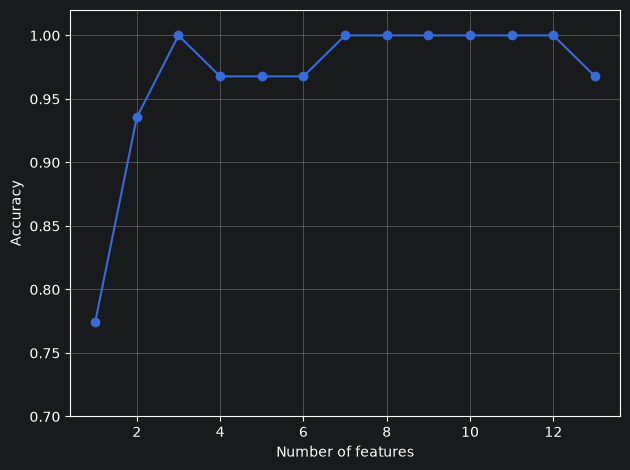

In [80]:

# Plot the number of features against the corresponding accuracy scores
plt.plot(k_feat, sbs.scores_, marker='o')  # Plot accuracy vs number of features with marker at each point
plt.ylim([0.7, 1.02])  # Set y-axis limits to zoom in on accuracy scores
plt.ylabel('Accuracy')  # Label y-axis as "Accuracy"
plt.xlabel('Number of features')  # Label x-axis as "Number of features"
plt.grid()  # Add grid to the plot for better visualization
plt.tight_layout()  # Automatically adjust subplot parameters for better fitting in the figure

# Uncomment the following line to save the figure if needed
# plt.savefig('figures/04_09.png', dpi=300)

# Display the plot
plt.show()

In [81]:
k3 = list(sbs.subsets_[10])
print(k3)
print(df_wine.columns[1:][k3])

[0, 1, 11]
Index(['Alcohol', 'Malic acid', 'OD280/OD315 of diluted wines'], dtype='str')


In [82]:
#Model before SBS
knn.fit(X_train_std, y_train)
print('Training accuracy:', knn.score(X_train_std, y_train))
print('Test accuracy:', knn.score(X_test_std, y_test))


Training accuracy: 0.967741935483871
Test accuracy: 0.9629629629629629


In [83]:
#Accuracy after SBS
knn.fit(X_train_std[:, k3], y_train)
print('Training accuracy:', knn.score(X_train_std[:, k3], y_train))
print('Test accuracy:', knn.score(X_test_std[:, k3], y_test))

Training accuracy: 0.9516129032258065
Test accuracy: 0.9259259259259259


## PART 4: Feature Importance with Random Forests

### Plot the feature importance and identify the top 3 most important features. How does this compare to the features selected by SBS?

In [84]:
from sklearn.ensemble import RandomForestClassifier

feat_labels = df_wine.columns[1:]

forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(X_train, y_train)

importances = forest.feature_importances_

indices = np.argsort(importances)[::-1]

for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30,
                            feat_labels[indices[f]],
                            importances[indices[f]]))

 1) Proline                        0.183649
 2) Flavanoids                     0.167963
 3) Color intensity                0.167647
 4) OD280/OD315 of diluted wines   0.133626
 5) Alcohol                        0.105554
 6) Hue                            0.062349
 7) Total phenols                  0.055781
 8) Magnesium                      0.035847
 9) Malic acid                     0.027521
10) Proanthocyanins                0.024961
11) Nonflavanoid phenols           0.012290
12) Ash                            0.011516
13) Alcalinity of ash              0.011296


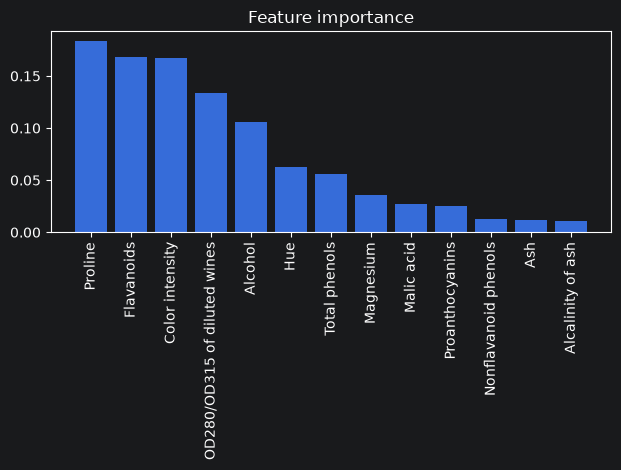

In [85]:
plt.title('Feature importance')
plt.bar(range(X_train.shape[1]),
        importances[indices],
        align='center')

plt.xticks(range(X_train.shape[1]),
           feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
# plt.savefig('figures/04_10.png', dpi=300)
plt.show()